# Analisis dan Segmentasi Developer serta Prediksi Penggunaan AI Tools

Notebook ini menggunakan dataset Stack Overflow Developer Survey 2025 sebagai baseline awal. Fokus target supervised learning adalah `AI_Usage`, yaitu apakah developer menggunakan AI tools atau tidak.

Pipeline utama:
1. Load dataset 2025.
2. Cek struktur kolom dan ketersediaan fitur.
3. Buat target `AI_Usage` dari `AISelect`.
4. Lakukan preprocessing tanpa memakai kolom AI sebagai fitur input.
5. Jalankan K-Means untuk segmentasi developer.
6. Latih Random Forest dan Linear SVM untuk prediksi penggunaan AI tools.
7. Simpan visualisasi, tabel, dan report ke folder `outputs`.

In [6]:
# 1. BASIC SETUP & PATH CONFIGURATION
# =========================================================

from pathlib import Path
import sys
import pandas as pd

# Import display tools (opsional untuk notebook)
from IPython.display import Image as Img, display

# ---------------------------------------------------------
# Menentukan root project secara dinamis
# Jika notebook dijalankan dari folder "notebooks",
# maka naik satu level ke root project
# ---------------------------------------------------------
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()

# Folder source code (modular ML pipeline)
SRC_DIR = PROJECT_ROOT / 'src'

# ---------------------------------------------------------
# Menambahkan src ke Python path agar module bisa di-import
# Ini penting agar file didalam src bisa dipanggil
# ---------------------------------------------------------
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))


# 2. OUTPUT DIRECTORY SETUP
# =========================================================

OUTPUT_ROOT = PROJECT_ROOT / 'outputs'

# Subfolder untuk hasil eksperimen
FIGURES_DIR = OUTPUT_ROOT / 'figures'   # visualisasi grafik
TABLES_DIR = OUTPUT_ROOT / 'tables'     # hasil tabel / metrics
REPORTS_DIR = OUTPUT_ROOT / 'reports'   # laporan evaluasi

# ---------------------------------------------------------
# Membuat folder jika belum ada
# exist_ok=True -> tidak error jika folder sudah ada
# ---------------------------------------------------------
for folder in [FIGURES_DIR, TABLES_DIR, REPORTS_DIR]:
    folder.mkdir(parents=True, exist_ok=True)


# 3. IMPORT MODULE DARI SRC (PIPELINE ML)
# =========================================================

# ---------------------------------------------------------
# DATA PREPROCESSING MODULE
# berisi:
# - load data
# - feature engineering
# - preprocessing pipeline
# ---------------------------------------------------------
from data_preprocessing import (
    CANDIDATE_FEATURES,          # fitur kandidat untuk model
    TARGET_SOURCE_COLUMN,        # kolom target awal
    build_preprocessor,          # membuat pipeline preprocessing
    find_dataset_path,           # mencari lokasi dataset
    inspect_candidate_columns,   # cek kolom dataset
    load_survey_data,            # load CSV survey
    prepare_model_data           # final dataset siap ML
)

# ---------------------------------------------------------
# EVALUATION MODULE
# berisi semua fungsi evaluasi model
# ---------------------------------------------------------
from evaluate_models import (
    evaluate_classification_models,  # evaluasi semua model
    plot_cluster_distribution,       # visual cluster
    plot_confusion_matrices,         # confusion matrix
    plot_gmm_metrics,                # evaluasi GMM
    plot_kmeans_metrics,             # evaluasi KMeans
    plot_model_comparison,          # perbandingan model
    save_classification_outputs     # simpan hasil evaluasi
)

# ---------------------------------------------------------
# TRAINING MODULE
# berisi semua model ML
# ---------------------------------------------------------
from train_models import (
    run_gmm_analysis,           # clustering GMM
    run_kmeans_analysis,        # clustering KMeans
    summarize_clusters,         # ringkasan cluster
    train_classification_models # training supervised models
)


# 4. PANDAS CONFIGURATION (DISPLAY SETTING)
# =========================================================

# ---------------------------------------------------------
# Agar tampilan dataframe tidak terpotong
# max_columns = jumlah kolom tampil penuh
# width = lebar output terminal/jupyter
# ---------------------------------------------------------
pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 160)

ImportError: cannot import name 'inspect_candidate_columns' from 'data_preprocessing' (c:\Dokumen\Semester 4\Machine Learning\Machine-AI\src\data_preprocessing.py)

## 1. Load Dataset 2025

In [16]:
from pathlib import Path
import pandas as pd

# =========================================================
# 1. SET PROJECT ROOT (FIXED VERSION)
# =========================================================

# naik 1 level dari notebooks → Machine-AI root
PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent


# =========================================================
# 2. DATA PATH (FIXED)
# =========================================================

DATA_PATH = PROJECT_ROOT / "Survey" / "packages" / "archive" / "2025" / "results.csv"

print("PROJECT ROOT:", PROJECT_ROOT)
print("DATA PATH:", DATA_PATH)

# cek file benar-benar ada
print("EXISTS?", DATA_PATH.exists())


# =========================================================
# 3. LOAD DATA (IMPORTANT FIX)
# =========================================================

# pastikan function ini sudah ada dari data_preprocessing.py
df = load_survey_data(DATA_PATH)

print("\nDATA LOADED SUCCESSFULLY")
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")

display(df.head())

PROJECT ROOT: c:\Dokumen\Semester 4\Machine Learning\Machine-AI
DATA PATH: c:\Dokumen\Semester 4\Machine Learning\Machine-AI\Survey\packages\archive\2025\results.csv
EXISTS? True



DATA LOADED SUCCESSFULLY
Shape: 49191 rows x 172 columns


,ResponseId,MainBranch,Age,EdLevel,Employment,EmploymentAddl,WorkExp,LearnCodeChoose,LearnCode,LearnCodeAI,AILearnHow,YearsCode,DevType,OrgSize,ICorPM,RemoteWork,PurchaseInfluence,TechEndorseIntro,TechEndorse_1,TechEndorse_2,TechEndorse_3,TechEndorse_4,TechEndorse_5,TechEndorse_6,TechEndorse_7,TechEndorse_8,TechEndorse_9,TechEndorse_13,TechEndorse_13_TEXT,TechOppose_1,TechOppose_2,TechOppose_3,TechOppose_5,TechOppose_7,TechOppose_9,TechOppose_11,TechOppose_13,TechOppose_16,TechOppose_15,TechOppose_15_TEXT,Industry,JobSatPoints_1,JobSatPoints_2,JobSatPoints_3,JobSatPoints_4,JobSatPoints_5,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,JobSatPoints_13,JobSatPoints_14,JobSatPoints_15,JobSatPoints_16,JobSatPoints_15_TEXT,AIThreat,NewRole,ToolCountWork,...,AIModelsHaveWorkedWith,AIModelsWantToWorkWith,AIModelsAdmired,AIModelsHaveEntry,AIModelsWantEntry,SOAccount,SOVisitFreq,SODuration,SOPartFreq,SO_Dev_Content,SO_Actions_1,SO_Actions_16,SO_Actions_3,SO_Actions_4,SO_Actions_5,SO_Actions_6,SO_Actions_9,SO_Actions_7,SO_Actions_10,SO_Actions_15,SO_Actions_15_TEXT,SOComm,SOFriction,AISelect,AISent,AIAcc,AIComplex,AIToolCurrently partially AI,AIToolDon't plan to use AI for this task,AIToolPlan to partially use AI,AIToolPlan to mostly use AI,AIToolCurrently mostly AI,AIFrustration,AIExplain,AIAgents,AIAgentChange,AIAgent_Uses,AgentUsesGeneral,AIAgentImpactSomewhat agree,AIAgentImpactNeutral,AIAgentImpactSomewhat disagree,AIAgentImpactStrongly agree,AIAgentImpactStrongly disagree,AIAgentChallengesNeutral,AIAgentChallengesSomewhat disagree,AIAgentChallengesStrongly agree,AIAgentChallengesSomewhat agree,AIAgentChallengesStrongly disagree,AIAgentKnowledge,AIAgentKnowWrite,AIAgentOrchestration,AIAgentOrchWrite,AIAgentObserveSecure,AIAgentObsWrite,AIAgentExternal,AIAgentExtWrite,AIHuman,AIOpen,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,25-34 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Employed,"Caring for dependents (children, elderly, etc.)",8.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",AI CodeGen tools or AI-enabled apps,14.0,"Developer, mobile",20 to 99 employees,People manager,Remote,"Yes, I influenced the purchase of a substantia...",Work,10.0,7.0,9.0,6.0,3.0,11.0,12.0,1.0,8.0,14.0,NaN,15.0,7.0,8.0,12.0,11.0,1.0,6.0,13.0,3.0,16.0,NaN,Fintech,3.0,1.0,4.0,9.0,5.0,10.0,12.0,11.0,2.0,6.0,7.0,13.0,14.0,15.0,8.0,NaN,I'm not sure,I have neither consider or transitioned into a...,7.0,...,openAI GPT (chatbot models);openAI Image gener...,NaN,NaN,NaN,NaN,Yes,A few times per week,Between 5 and 10 years,I have never participated in Q&A on Stack Over...,NaN,1.0,NaN,6.0,2.0,3.0,7.0,8.0,9.0,11.0,15.0,NaN,Neutral,"Rarely, almost never","Yes, I use AI tools monthly or infrequently",Indifferent,Neither trust nor distrust,Bad at handling complex tasks,Learning about a codebase;Writing code;Search ...,Project planning;Deployment and monitoring;Lea...,Documenting code;Debugging or fixing code;Test...,NaN,NaN,"AI solutions that are almost right, but not quite",No,"Yes, I use AI agents at work monthly or infreq...",Not at all or minimally,Software engineering,NaN,AI agents have increased my productivity.;AI a...,AI agents have helped me automate repetitive t...,NaN,NaN,NaN,I am concerned about the accuracy of the infor...,Integrating AI agents with my existing tools a...,The cost of using certain AI agent platforms i...,NaN,NaN,NaN,NaN,Vertex AI,NaN,NaN,NaN,ChatGPT,NaN,When I don’t trust AI’s answers,"Troubleshooting, profiling, debugging",61256.0,10.0
1,2,I am a developer by profession,25-34 years old,"Associate degree (A.A., A.S., etc.)",Employed,NaN,2.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",AI CodeGen tools or AI-enabled apps,10.0,"Developer, back-end",500 

## 2. Cek Struktur Kolom

Langkah ini penting karena struktur kolom Stack Overflow Developer Survey bisa berubah antar tahun. Fitur yang tidak tersedia tidak dipaksakan masuk ke pipeline.

In [17]:
# =========================================================
# 2. CEK STRUKTUR KOLOM DATASET
# =========================================================

import pandas as pd
from IPython.display import display

# ---------------------------------------------------------
# 1. Buat ringkasan semua kolom dataset
# ---------------------------------------------------------
columns_df = pd.DataFrame({"column": df.columns})

# simpan ke file
columns_df.to_csv(TABLES_DIR / "available_columns_2025.csv", index=False)


# ---------------------------------------------------------
# 2. Cek ketersediaan fitur kandidat
# ---------------------------------------------------------
feature_availability = inspect_candidate_columns(df, CANDIDATE_FEATURES)

feature_availability.to_csv(
    TABLES_DIR / "candidate_feature_availability_2025.csv",
    index=False
)


# ---------------------------------------------------------
# 3. Info jumlah kolom
# ---------------------------------------------------------
print("Jumlah kolom tersedia:", len(df.columns))
display(feature_availability)


# ---------------------------------------------------------
# 4. CEK TARGET COLUMN (AI usage)
# ---------------------------------------------------------
if TARGET_SOURCE_COLUMN in df.columns:

    print("\nTarget ditemukan:", TARGET_SOURCE_COLUMN)

    target_distribution = (
        df[TARGET_SOURCE_COLUMN]
        .value_counts(dropna=False)
        .rename("count")
        .to_frame()
    )

    display(target_distribution)

else:

    # -----------------------------------------------------
    # kalau target tidak ditemukan → cari kolom AI
    # -----------------------------------------------------
    ai_like_columns = [col for col in df.columns if "ai" in col.lower()]

    print(f"\n❌ Kolom target '{TARGET_SOURCE_COLUMN}' tidak ditemukan.")
    print("\nKolom yang mengandung kata 'AI':")

    for col in ai_like_columns:
        print("-", col)

    print("\n👉 SOLUSI:")
    print("Sesuaikan TARGET_SOURCE_COLUMN di notebook atau data_preprocessing.py")

Jumlah kolom tersedia: 172


,column,available
0,Age,True
1,Country,True
2,EdLevel,True
3,DevType,True
4,Employment,True
5,RemoteWork,True
6,YearsCode,True
7,YearsCodePro,False
8,LanguageHaveWorkedWith,True
9,DatabaseHaveWorkedWith,True



Target ditemukan: AISelect


,count
AISelect,
"Yes, I use AI tools daily",15883
NaN,15471
"Yes, I use AI tools weekly",5958
"No, and I don't plan to",5454
"Yes, I use AI tools monthly or infrequently",4628
"No, but I plan to soon",1797


## 3. Bentuk Target dan Pilih Fitur

`AI_Usage` dibuat dari `AISelect`:
- `1`: jawaban dimulai dengan `Yes`.
- `0`: jawaban dimulai dengan `No`.

Kolom AI lain tidak digunakan sebagai fitur agar tidak terjadi data leakage.

In [19]:
# =========================================================
# 3. BENTUK TARGET DAN PILIH FITUR
# =========================================================

from IPython.display import display

print("=================================================")
print("STEP 3: TARGET ENGINEERING & FEATURE SELECTION")
print("=================================================\n")


# =========================================================
# 1. AMBIL X, y DARI PIPELINE PREPROCESSING
# =========================================================

try:
    X, y, metadata = prepare_model_data(df)

except KeyError as error:
    print("\n❌ ERROR TERDETEKSI:")
    print(error)

    print("\n📌 SOLUSI:")
    print("- Cek file outputs/tables/available_columns_2025.csv")
    print("- Pastikan TARGET_SOURCE_COLUMN sesuai dataset")

    raise


# =========================================================
# 2. INFO DATASET SETELAH PREPROCESSING
# =========================================================

print("\n================ DATA SUMMARY ================\n")

print(f"Jumlah data setelah cleaning: {metadata['n_rows_after_target_drop']:,}")
print(f"Jumlah fitur digunakan: {len(metadata['available_features'])}")
print(f"Jumlah fitur tidak tersedia: {len(metadata['missing_features'])}")


# =========================================================
# 3. FEATURE YANG DIGUNAKAN
# =========================================================

print("\n================ FEATURES USED ================\n")

for feat in metadata["available_features"]:
    print("-", feat)


# =========================================================
# 4. FEATURE YANG TIDAK TERSEDIA
# =========================================================

print("\n============= MISSING FEATURES =============\n")

if metadata["missing_features"]:
    for feat in metadata["missing_features"]:
        print("-", feat)
else:
    print("Tidak ada missing feature")


# =========================================================
# 5. DISTRIBUSI TARGET AI_USAGE
# =========================================================

print("\n============= TARGET DISTRIBUTION =============\n")

target_distribution = (
    y.value_counts()
    .sort_index()
    .rename_axis("AI_Usage")
    .reset_index(name="count")
)

# mapping label biar human readable
target_distribution["label"] = target_distribution["AI_Usage"].map({
    0: "Tidak menggunakan AI",
    1: "Menggunakan AI"
})

display(target_distribution)

# simpan ke file
target_distribution.to_csv(
    TABLES_DIR / "target_distribution_2025.csv",
    index=False
)


# =========================================================
# 6. CEK SAMPLE DATASET
# =========================================================

print("\n============= SAMPLE FEATURES (X.head) =============\n")

display(X.head())


# =========================================================
# 7. VALIDATION CHECK (IMPORTANT)
# =========================================================

print("\n============= VALIDATION CHECK =============\n")

print("Shape X:", X.shape)
print("Shape y:", y.shape)

print("\nMissing values di target:", y.isna().sum())

print("\nDistribusi final target:")
print(y.value_counts())

STEP 3: TARGET ENGINEERING & FEATURE SELECTION


================ DATA SUMMARY ================

Jumlah data setelah cleaning: 33,720
Jumlah fitur digunakan: 11
Jumlah fitur tidak tersedia: 2

================ FEATURES USED ================

- Age
- Country
- EdLevel
- DevType
- Employment
- RemoteWork
- YearsCode
- LanguageHaveWorkedWith
- DatabaseHaveWorkedWith
- PlatformHaveWorkedWith
- WebframeHaveWorkedWith

============= MISSING FEATURES =============

- YearsCodePro
- ToolsTechHaveWorkedWith

============= TARGET DISTRIBUTION =============



,AI_Usage,count,label
0,0,7251,Tidak menggunakan AI
1,1,26469,Menggunakan AI



============= SAMPLE FEATURES (X.head) =============



,Age,Country,EdLevel,DevType,Employment,RemoteWork,YearsCode,LanguageHaveWorkedWith,DatabaseHaveWorkedWith,PlatformHaveWorkedWith,WebframeHaveWorkedWith
0,25-34 years old,Ukraine,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)","Developer, mobile",Employed,Remote,14.0,Bash/Shell (all shells);Dart;SQL,Cloud Firestore;PostgreSQL,Amazon Web Services (AWS);Cloudflare;Firebase;...,NaN
1,25-34 years old,Netherlands,"Associate degree (A.A., A.S., etc.)","Developer, back-end",Employed,"Hybrid (some in-person, leans heavy to flexibi...",10.0,Java,Dynamodb;MongoDB,Amazon Web Services (AWS);Datadog;Docker;Homeb...,Spring Boot
2,35-44 years old,Ukraine,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Developer, front-end","Independent contractor, freelancer, or self-em...",NaN,12.0,Dart;HTML/CSS;JavaScript;TypeScript,MongoDB;MySQL;PostgreSQL,Datadog;Firebase;npm;pnpm,Next.js;Node.js;React
3,35-44 years old,Ukraine,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Developer, back-end",Employed,Remote,5.0,Java;Kotlin;SQL,NaN,Amazon Web Services (AWS);Google Cloud,Spring Boot
4,35-44 years old,Ukraine,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Engineering manager,"Independent contractor, freelancer, or self-em...",NaN,22.0,C;C#;C++;Delphi;HTML/CSS;Java;JavaScript;Lua;P...,Elasticsearch;Microsoft SQL Server;MySQL;Oracl...,Amazon Web Services (AWS);APT;Docker;Make;Mave...,Angular;ASP.NET;ASP.NET Core;Flask;jQuery



============= VALIDATION CHECK =============

Shape X: (33720, 11)
Shape y: (33720,)

Missing values di target: 0

Distribusi final target:
AI_Usage
1    26469
0     7251
Name: count, dtype: int64


## 4. Preprocessing

Preprocessing yang digunakan:
- Missing value numerik: median.
- Missing value kategorikal: `Unknown`.
- `YearsCode` dan `YearsCodePro`: dikonversi ke numerik jika tersedia.
- Kategorikal biasa: One-Hot Encoding.
- Multi-select dengan pemisah `;`: tokenisasi biner.
- Numerik: StandardScaler.

In [20]:
# =========================================================
# 4. PREPROCESSING PIPELINE
# =========================================================

from IPython.display import display
import pandas as pd

print("=================================================")
print("STEP 4: PREPROCESSING PIPELINE")
print("=================================================\n")


# ---------------------------------------------------------
# Penjelasan preprocessing (untuk laporan)
# ---------------------------------------------------------
print("""
Preprocessing yang digunakan:

1. Missing value numerik → median imputation
2. Missing value kategorikal → "Unknown"
3. YearsCode & YearsCodePro → dikonversi ke numerik
4. Kategorikal → One-Hot Encoding
5. Multi-select (pakai ';') → tokenisasi + binary vector
6. Numerik → StandardScaler
""")


# ---------------------------------------------------------
# BUILD PREPROCESSOR
# ---------------------------------------------------------
preprocessor, feature_groups = build_preprocessor(X)


# ---------------------------------------------------------
# TAMPILKAN FEATURE GROUPS (FIXED FORMAT)
# ---------------------------------------------------------

feature_groups_df = pd.DataFrame(
    {
        "feature_group": list(feature_groups.keys()),
        "columns": [", ".join(v) if isinstance(v, list) else str(v) for v in feature_groups.values()]
    }
)

display(feature_groups_df)


# ---------------------------------------------------------
# INFO TAMBAHAN UNTUK DEBUGGING
# ---------------------------------------------------------
print("\n============= FEATURE SUMMARY =============\n")

for group_name, cols in feature_groups.items():
    print(f"{group_name.upper()}:")
    print(cols)
    print()

STEP 4: PREPROCESSING PIPELINE


Preprocessing yang digunakan:

1. Missing value numerik → median imputation
2. Missing value kategorikal → "Unknown"
3. YearsCode & YearsCodePro → dikonversi ke numerik
4. Kategorikal → One-Hot Encoding
5. Multi-select (pakai ';') → tokenisasi + binary vector
6. Numerik → StandardScaler



,feature_group,columns
0,numeric_features,YearsCode
1,categorical_features,"Age, Country, EdLevel, DevType, Employment, Re..."
2,multi_select_features,"LanguageHaveWorkedWith, DatabaseHaveWorkedWith..."



============= FEATURE SUMMARY =============

NUMERIC_FEATURES:
['YearsCode']

CATEGORICAL_FEATURES:
['Age', 'Country', 'EdLevel', 'DevType', 'Employment', 'RemoteWork']

MULTI_SELECT_FEATURES:
['LanguageHaveWorkedWith', 'DatabaseHaveWorkedWith', 'PlatformHaveWorkedWith', 'WebframeHaveWorkedWith']



## 5. K-Means Clustering

K-Means digunakan untuk segmentasi developer. Nilai `k` dievaluasi dengan Elbow Method dan Silhouette Score. Untuk menjaga clustering tetap praktis pada fitur one-hot yang banyak, fitur hasil preprocessing direduksi lebih dahulu dengan TruncatedSVD.

In [21]:
# =========================================================
# 5. K-MEANS CLUSTERING
# =========================================================

from IPython.display import display

print("=================================================")
print("STEP 5: K-MEANS CLUSTERING")
print("=================================================\n")


# ---------------------------------------------------------
# PENJELASAN METODE (UNTUK LAPORAN)
# ---------------------------------------------------------
print("""
K-Means digunakan untuk segmentasi developer berdasarkan pola perilaku.

Metode evaluasi:
- Elbow Method → melihat penurunan inertia
- Silhouette Score → kualitas pemisahan cluster

Karena fitur hasil preprocessing sangat tinggi (one-hot + multi-label),
digunakan TruncatedSVD untuk reduksi dimensi sebelum clustering.
""")


# ---------------------------------------------------------
# TRAIN K-MEANS MODEL
# ---------------------------------------------------------
kmeans_result = run_kmeans_analysis(
    X,
    preprocessor,
    k_values=range(2, 11)
)


# ---------------------------------------------------------
# AMBIL HASIL
# ---------------------------------------------------------
kmeans_metrics = kmeans_result["metrics"]
best_k = kmeans_result["best_k"]
cluster_labels = kmeans_result["labels"]


# ---------------------------------------------------------
# SIMPAN HASIL METRICS
# ---------------------------------------------------------
kmeans_metrics.to_csv(
    TABLES_DIR / "kmeans_elbow_silhouette.csv",
    index=False
)


# ---------------------------------------------------------
# VISUALISASI
# ---------------------------------------------------------
plot_kmeans_metrics(kmeans_metrics, OUTPUT_ROOT)


# ---------------------------------------------------------
# OUTPUT INFO
# ---------------------------------------------------------
print("\n============= HASIL K-MEANS =============\n")

print(f"Jumlah cluster terbaik (k): {best_k}")

print("\nRingkasan metrics:")
display(kmeans_metrics)


# ---------------------------------------------------------
# OPSIONAL: CEK DISTRIBUSI CLUSTER
# ---------------------------------------------------------
import pandas as pd

cluster_distribution = (
    pd.Series(cluster_labels)
    .value_counts()
    .sort_index()
    .rename_axis("Cluster")
    .reset_index(name="Jumlah Data")
)

display(cluster_distribution)

STEP 5: K-MEANS CLUSTERING


K-Means digunakan untuk segmentasi developer berdasarkan pola perilaku.

Metode evaluasi:
- Elbow Method → melihat penurunan inertia
- Silhouette Score → kualitas pemisahan cluster

Karena fitur hasil preprocessing sangat tinggi (one-hot + multi-label),
digunakan TruncatedSVD untuk reduksi dimensi sebelum clustering.


============= HASIL K-MEANS =============

Jumlah cluster terbaik (k): 2

Ringkasan metrics:


,k,inertia,silhouette_score
0,2,1.640901e+06,0.048200
1,3,1.613067e+06,0.004959
2,4,1.585755e+06,0.015395
3,5,1.566427e+06,0.017007
4,6,1.523395e+06,0.046285
5,7,1.531641e+06,-0.025045
6,8,1.490875e+06,0.033930
7,9,1.480808e+06,0.034155
8,10,1.470657e+06,-0.051364


,Cluster,Jumlah Data
0,0,14885
1,1,18835


IMAGE PATH: c:\Dokumen\Semester 4\Machine Learning\Machine-AI\outputs\figures\kmeans_elbow_silhouette.png
EXISTS: True


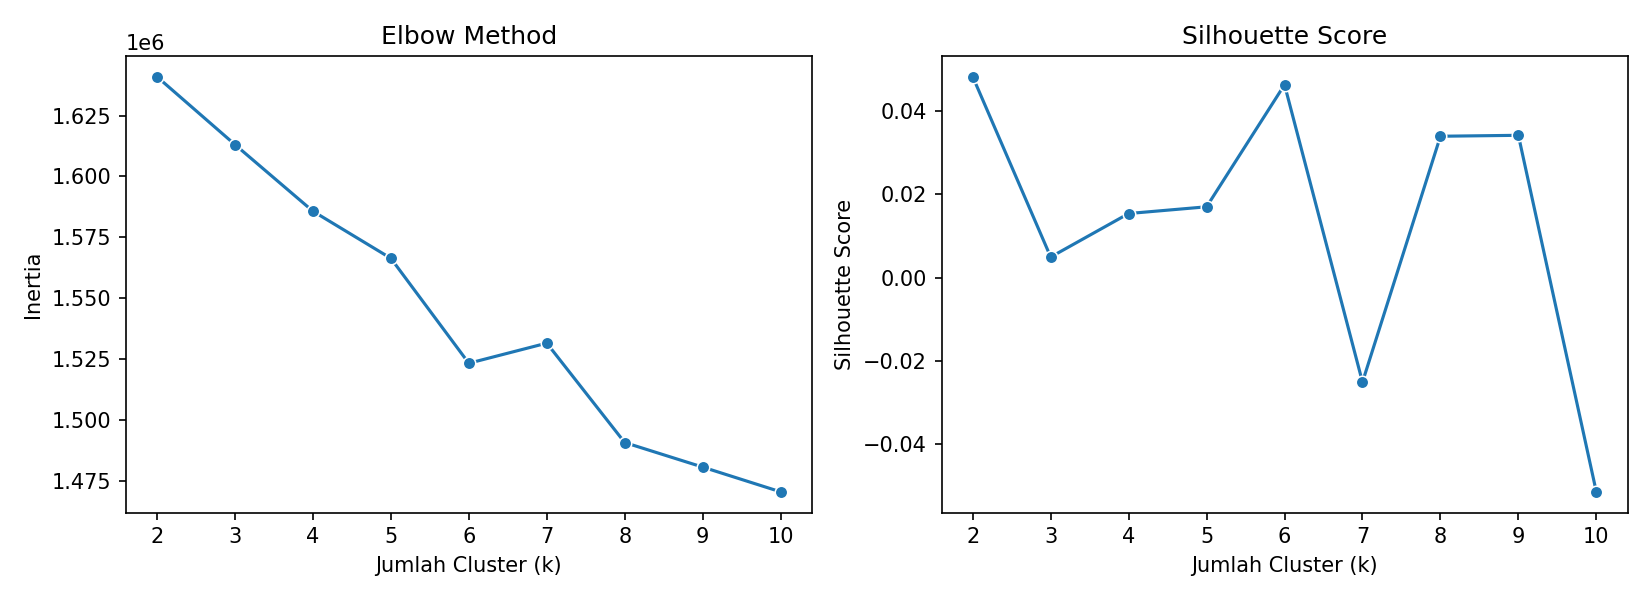

In [22]:
from IPython.display import Image, display
from pathlib import Path

img_path = FIGURES_DIR / "kmeans_elbow_silhouette.png"

print("IMAGE PATH:", img_path)
print("EXISTS:", img_path.exists())

if img_path.exists():
    display(Image(filename=str(img_path)))
else:
    print("❌ Gambar tidak ditemukan. Jalankan plot_kmeans_metrics dulu.")

In [24]:
# =========================================================
# 6. K-MEANS CLUSTER SUMMARY
# =========================================================

from IPython.display import display

print("=================================================")
print("STEP 6: CLUSTER ANALYSIS (K-MEANS SUMMARY)")
print("=================================================\n")


# ---------------------------------------------------------
# 1. GENERATE CLUSTER SUMMARY
# ---------------------------------------------------------
cluster_summary = summarize_clusters(X, cluster_labels)


# ---------------------------------------------------------
# 2. SAVE HASIL KE FILE CSV
# ---------------------------------------------------------
cluster_summary.to_csv(
    TABLES_DIR / "kmeans_cluster_summary.csv",
    index=False
)


# ---------------------------------------------------------
# 3. VISUALISASI DISTRIBUSI CLUSTER
# ---------------------------------------------------------
plot_cluster_distribution(
    cluster_summary,
    OUTPUT_ROOT,
    prefix="kmeans_"
)


# ---------------------------------------------------------
# 4. TAMPILKAN HASIL SUMMARY
# ---------------------------------------------------------
print("\n============= CLUSTER SUMMARY =============\n")

display(cluster_summary)


# ---------------------------------------------------------
# 5. INFO TAMBAHAN (UNTUK LAPORAN)
# ---------------------------------------------------------
print("\n============= INTERPRETASI DASAR =============\n")

for col in cluster_summary.columns:
    if col not in ["Cluster", "Jumlah_Data", "Persentase"]:
        print(f"{col} → sudah dirangkum per cluster")

STEP 6: CLUSTER ANALYSIS (K-MEANS SUMMARY)


============= CLUSTER SUMMARY =============



,Cluster,Jumlah_Data,Persentase,Age_Dominan,Country_Dominan,EdLevel_Dominan,DevType_Dominan,Employment_Dominan,RemoteWork_Dominan,YearsCode_Rata_Rata,LanguageHaveWorkedWith_Dominan,DatabaseHaveWorkedWith_Dominan,PlatformHaveWorkedWith_Dominan,WebframeHaveWorkedWith_Dominan
0,0,14885,44.142942,25-34 years old (5288); 35-44 years old (4680)...,United States of America (3231); Germany (1328...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.) (...","Developer, full-stack (6078); Developer, back-...","Employed (11123); Independent contractor, free...","Remote (4397); Hybrid (some in-person, leans h...",16.897034,JavaScript (13123); HTML/CSS (11892); TypeScri...,PostgreSQL (9237); MySQL (6403); SQLite (5996)...,npm (13440); Docker (11958); Pip (7290); Amazo...,Node.js (9146); React (8039); Express (3862); ...
1,1,18835,55.857058,25-34 years old (5667); 35-44 years old (4782)...,United States of America (3707); Germany (1604...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.) (...","Developer, full-stack (3476); Developer, back-...","Employed (12821); Independent contractor, free...","Remote (4269); Hybrid (some remote, leans heav...",17.442700,Python (8937); SQL (7705); JavaScript (7411); ...,PostgreSQL (5025); MySQL (3925); SQLite (3630)...,Docker (5210); Amazon Web Services (AWS) (3187...,React (2389); Node.js (2231); jQuery (1868); A...



============= INTERPRETASI DASAR =============

Age_Dominan → sudah dirangkum per cluster
Country_Dominan → sudah dirangkum per cluster
EdLevel_Dominan → sudah dirangkum per cluster
DevType_Dominan → sudah dirangkum per cluster
Employment_Dominan → sudah dirangkum per cluster
RemoteWork_Dominan → sudah dirangkum per cluster
YearsCode_Rata_Rata → sudah dirangkum per cluster
LanguageHaveWorkedWith_Dominan → sudah dirangkum per cluster
DatabaseHaveWorkedWith_Dominan → sudah dirangkum per cluster
PlatformHaveWorkedWith_Dominan → sudah dirangkum per cluster
WebframeHaveWorkedWith_Dominan → sudah dirangkum per cluster


### Catatan Interpretasi Cluster

Gunakan tabel `cluster_summary.csv` untuk BAB IV. Interpretasi dapat ditulis dengan pola berikut:
- Cluster dengan dominasi negara/tipe developer tertentu dapat dijelaskan sebagai segmen geografis atau peran kerja tertentu.
- Rata-rata `YearsCode` menunjukkan tingkat pengalaman coding pada cluster.
- Bahasa, database, platform, dan web framework dominan menunjukkan profil teknologi yang sering digunakan oleh cluster tersebut.
- Distribusi jumlah data per cluster menunjukkan apakah segmentasi relatif seimbang atau ada cluster yang sangat dominan.

STEP 7: CLUSTER VISUALIZATION

File path: c:\Dokumen\Semester 4\Machine Learning\Machine-AI\outputs\figures\kmeans_cluster_distribution.png
Exists: True


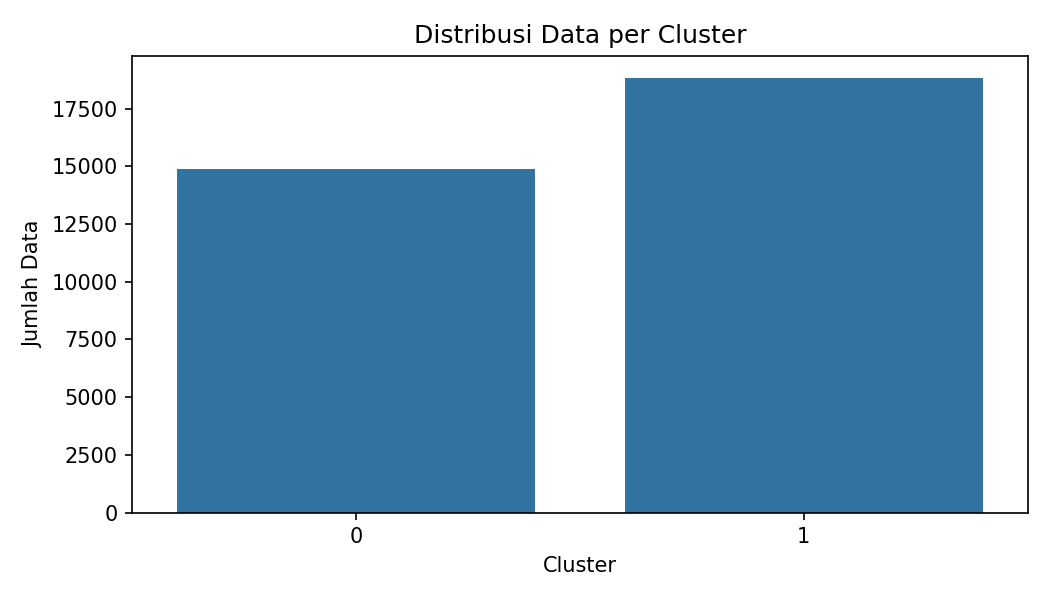


================ INTERPRETASI CLUSTER ================


Gunakan tabel cluster_summary.csv untuk analisis BAB IV.

Panduan interpretasi:

1. Segmentasi Geografis / Profesi
   - Cluster dengan dominasi negara tertentu menunjukkan perbedaan distribusi geografis developer.
   - Dominasi DevType menunjukkan role pekerjaan utama dalam cluster.

2. Tingkat Pengalaman
   - Rata-rata YearsCode dan YearsCodePro menunjukkan level pengalaman developer.
   - Cluster dengan nilai tinggi → senior developer.
   - Cluster dengan nilai rendah → junior / entry-level.

3. Profil Teknologi
   - Bahasa pemrograman dominan menunjukkan stack utama cluster.
   - Database, platform, dan framework menunjukkan ekosistem kerja.

4. Distribusi Cluster
   - Cluster dengan jumlah besar menunjukkan segmen utama developer.
   - Cluster kecil menunjukkan niche / spesialisasi tertentu.

Kesimpulan:
Clustering ini digunakan untuk memahami segmentasi developer berdasarkan
perilaku teknologi, pengalaman, dan lingkungan ke

In [26]:
# =========================================================
# 7. VISUALISASI DISTRIBUSI CLUSTER + INTERPRETASI
# =========================================================

from IPython.display import Image, display
from pathlib import Path

print("=================================================")
print("STEP 7: CLUSTER VISUALIZATION")
print("=================================================\n")


# ---------------------------------------------------------
# 1. PATH GAMBAR
# ---------------------------------------------------------
img_path = FIGURES_DIR / "kmeans_cluster_distribution.png"

print("File path:", img_path)
print("Exists:", img_path.exists())


# ---------------------------------------------------------
# 2. DISPLAY GAMBAR DENGAN SAFETY CHECK
# ---------------------------------------------------------
if img_path.exists():
    display(Image(filename=str(img_path)))
else:
    print("❌ Gambar tidak ditemukan.")
    print("Pastikan plot_cluster_distribution sudah dijalankan sebelumnya.")


# ---------------------------------------------------------
# 3. INTERPRETASI CLUSTER (UNTUK LAPORAN BAB IV)
# ---------------------------------------------------------
print("\n================ INTERPRETASI CLUSTER ================\n")

interpretation_text = """
Gunakan tabel cluster_summary.csv untuk analisis BAB IV.

Panduan interpretasi:

1. Segmentasi Geografis / Profesi
   - Cluster dengan dominasi negara tertentu menunjukkan perbedaan distribusi geografis developer.
   - Dominasi DevType menunjukkan role pekerjaan utama dalam cluster.

2. Tingkat Pengalaman
   - Rata-rata YearsCode dan YearsCodePro menunjukkan level pengalaman developer.
   - Cluster dengan nilai tinggi → senior developer.
   - Cluster dengan nilai rendah → junior / entry-level.

3. Profil Teknologi
   - Bahasa pemrograman dominan menunjukkan stack utama cluster.
   - Database, platform, dan framework menunjukkan ekosistem kerja.

4. Distribusi Cluster
   - Cluster dengan jumlah besar menunjukkan segmen utama developer.
   - Cluster kecil menunjukkan niche / spesialisasi tertentu.

Kesimpulan:
Clustering ini digunakan untuk memahami segmentasi developer berdasarkan
perilaku teknologi, pengalaman, dan lingkungan kerja.
"""

print(interpretation_text)

## 5b. GMM Clustering (Modern - Probabilistic)

GMM adalah soft clustering modern yang memberikan probabilitas setiap data
masuk ke tiap cluster. Evaluasi menggunakan BIC, AIC, dan Silhouette Score.


In [27]:
# =========================================================
# 5B. GMM CLUSTERING (MODERN - PROBABILISTIC)
# =========================================================

from IPython.display import display

print("=================================================")
print("STEP 5B: GMM CLUSTERING (MODERN)")
print("=================================================\n")


# ---------------------------------------------------------
# PENJELASAN METODE
# ---------------------------------------------------------
print("""
GMM (Gaussian Mixture Model) adalah metode soft clustering.

Perbedaan dengan K-Means:
- K-Means → hard clustering (1 data = 1 cluster)
- GMM → probabilistic clustering (1 data punya probabilitas di tiap cluster)

Evaluasi model:
- BIC (Bayesian Information Criterion)
- AIC (Akaike Information Criterion)
- Silhouette Score
""")


# ---------------------------------------------------------
# TRAIN GMM MODEL
# ---------------------------------------------------------
gmm_result = run_gmm_analysis(
    X,
    preprocessor,
    k_values=range(2, 9)
)


# ---------------------------------------------------------
# AMBIL HASIL
# ---------------------------------------------------------
gmm_metrics = gmm_result["metrics"]
gmm_best_k = gmm_result["best_k"]


# ---------------------------------------------------------
# SIMPAN METRICS
# ---------------------------------------------------------
gmm_metrics.to_csv(
    TABLES_DIR / "gmm_bic_silhouette.csv",
    index=False
)


# ---------------------------------------------------------
# VISUALISASI METRICS
# ---------------------------------------------------------
plot_gmm_metrics(gmm_metrics, OUTPUT_ROOT)


# ---------------------------------------------------------
# OUTPUT HASIL
# ---------------------------------------------------------
print("\n============= HASIL GMM =============\n")

print(f"GMM best k (berdasarkan silhouette): {gmm_best_k}")

print("\nMetrics detail:")
display(gmm_metrics)


# ---------------------------------------------------------
# OPSIONAL: CEK PROBABILITAS CLUSTER
# ---------------------------------------------------------
if "probabilities" in gmm_result:

    import pandas as pd

    prob_df = pd.DataFrame(
        gmm_result["probabilities"],
        columns=[f"Cluster_{i}" for i in range(gmm_result["probabilities"].shape[1])]
    )

    print("\n============= SAMPLE PROBABILITAS CLUSTER =============\n")
    display(prob_df.head())

STEP 5B: GMM CLUSTERING (MODERN)


GMM (Gaussian Mixture Model) adalah metode soft clustering.

Perbedaan dengan K-Means:
- K-Means → hard clustering (1 data = 1 cluster)
- GMM → probabilistic clustering (1 data punya probabilitas di tiap cluster)

Evaluasi model:
- BIC (Bayesian Information Criterion)
- AIC (Akaike Information Criterion)
- Silhouette Score


============= HASIL GMM =============

GMM best k (berdasarkan silhouette): 8

Metrics detail:


,k,bic,aic,silhouette_score
0,2,2.586786e+06,2.578436e+06,-0.035249
1,3,2.504670e+06,2.492141e+06,-0.034615
2,4,2.452637e+06,2.435928e+06,-0.026742
3,5,2.403949e+06,2.383061e+06,-0.027585
4,6,2.379480e+06,2.354413e+06,-0.022688
5,7,2.325563e+06,2.296317e+06,-0.032051
6,8,2.308654e+06,2.275229e+06,-0.018893



============= SAMPLE PROBABILITAS CLUSTER =============



,Cluster_0,Cluster_1,Cluster_2,Cluster_3,Cluster_4,Cluster_5,Cluster_6,Cluster_7
0,2.718596e-58,2.757044e-69,9.999996e-01,0.0,1.136351e-322,7.425831e-19,3.779088e-07,4.404928e-152
1,7.627847e-181,7.852763e-01,1.015267e-116,0.0,9.420408e-220,2.147221e-01,1.645312e-06,1.736313e-116
2,3.114284e-04,1.303715e-04,1.148160e-72,0.0,6.854182e-275,9.995582e-01,7.877377e-09,0.000000e+00
3,1.105324e-112,2.906700e-76,1.000000e+00,0.0,0.000000e+00,1.654021e-16,1.502914e-11,1.281821e-154
4,5.748057e-212,2.585561e-06,1.895747e-106,0.0,1.198900e-246,9.999919e-01,5.521007e-06,0.000000e+00


In [28]:
# =========================================================
# 6B. GMM CLUSTER SUMMARY
# =========================================================

from IPython.display import display

print("=================================================")
print("STEP 6B: GMM CLUSTER SUMMARY")
print("=================================================\n")


# ---------------------------------------------------------
# 1. GENERATE SUMMARY
# ---------------------------------------------------------
gmm_cluster_summary = summarize_clusters(X, gmm_result["labels"])


# ---------------------------------------------------------
# 2. SAVE OUTPUT
# ---------------------------------------------------------
gmm_cluster_summary.to_csv(
    TABLES_DIR / "gmm_cluster_summary.csv",
    index=False
)


# ---------------------------------------------------------
# 3. VISUALISASI DISTRIBUSI CLUSTER
# ---------------------------------------------------------
plot_cluster_distribution(
    gmm_cluster_summary,
    OUTPUT_ROOT,
    prefix="gmm_"
)


# ---------------------------------------------------------
# 4. TAMPILKAN HASIL
# ---------------------------------------------------------
print("\n============= GMM CLUSTER SUMMARY =============\n")

display(gmm_cluster_summary)


# ---------------------------------------------------------
# 5. INTERPRETASI SINGKAT (UNTUK LAPORAN)
# ---------------------------------------------------------
print("\n============= INTERPRETASI GMM CLUSTERS =============\n")

print("""
1. GMM menghasilkan soft clustering berbasis probabilitas distribusi Gaussian.
2. Setiap cluster merepresentasikan segmen developer dengan pola berbeda.
3. Perbedaan utama antar cluster terlihat pada:
   - tingkat pengalaman (YearsCode)
   - bahasa pemrograman dominan
   - jenis pekerjaan (DevType)
   - lingkungan kerja (RemoteWork)
4. Cluster dengan ukuran besar menunjukkan segmen mayoritas developer.
5. Cluster kecil menunjukkan niche developer dengan spesialisasi tertentu.

Kesimpulan:
GMM memberikan segmentasi yang lebih fleksibel dibanding K-Means karena
mempertimbangkan distribusi data secara probabilistik.
""")

STEP 6B: GMM CLUSTER SUMMARY


============= GMM CLUSTER SUMMARY =============



,Cluster,Jumlah_Data,Persentase,Age_Dominan,Country_Dominan,EdLevel_Dominan,DevType_Dominan,Employment_Dominan,RemoteWork_Dominan,YearsCode_Rata_Rata,LanguageHaveWorkedWith_Dominan,DatabaseHaveWorkedWith_Dominan,PlatformHaveWorkedWith_Dominan,WebframeHaveWorkedWith_Dominan
0,0,2989,8.864176,25-34 years old (886); 35-44 years old (834); ...,United States of America (688); United Kingdom...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.) (...","Developer, full-stack (983); Developer, front-...","Employed (2076); Independent contractor, freel...",Remote (926); In-person (522); Hybrid (some in...,20.436037,JavaScript (1866); HTML/CSS (1827); SQL (1792)...,Microsoft SQL Server (1333); MySQL (736); SQLi...,Microsoft Azure (691); NuGet (458); npm (395);...,ASP.NET Core (778); jQuery (700); React (643);...
1,1,5518,16.364176,25-34 years old (1845); 35-44 years old (1651)...,United States of America (1113); Germany (623)...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc....","Developer, back-end (857); Developer, full-sta...","Employed (3623); Independent contractor, freel...","Hybrid (some in-person, leans heavy to flexibi...",20.741480,Python (3442); Bash/Shell (all shells) (2934);...,PostgreSQL (2038); SQLite (1435); MySQL (1345)...,Docker (2642); Pip (1763); Amazon Web Services...,Node.js (908); React (718); jQuery (483); Spri...
2,2,3972,11.779359,35-44 years old (1466); 25-34 years old (1274)...,United States of America (1271); Ukraine (243)...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.) (...","Developer, back-end (984); Developer, full-sta...","Employed (3476); Independent contractor, freel...",Remote (3972),19.048065,JavaScript (2318); Python (2224); SQL (2080); ...,PostgreSQL (2177); SQLite (1041); Redis (1034)...,Docker (2470); Amazon Web Services (AWS) (2001...,React (1318); Node.js (1188); Next.js (538); F...
3,3,3515,10.424081,25-34 years old (1108); 18-24 years old (805);...,United States of America (643); India (375); G...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.) (...","Developer, full-stack (520); Student (461); De...",Employed (1952); Student (525); Independent co...,Remote (792); In-person (715); Hybrid (some in...,15.614922,Python (784); C++ (624); C (551); Bash/Shell (...,,,
4,4,3162,9.377224,18-24 years old (3120); Prefer not to say (42),India (477); United States of America (452); G...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.) (...","Student (1385); Developer, full-stack (687); D...",Student (1681); Employed (1010); Not employed ...,"In-person (754); Your choice (very flexible, y...",5.976008,HTML/CSS (2311); Python (2293); JavaScript (22...,PostgreSQL (1258); MySQL (1181); SQLite (1037)...,Docker (1428); npm (1354); Pip (1187); Vite (7...,Node.js (1411); React (1256); Express (704); N...
5,5,6697,19.860617,25-34 years old (3512); 35-44 years old (3185),United States of America (1219); Germany (643)...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.) (...","Developer, full-stack (3196); Developer, back-...","Employed (5358); Independent contractor, freel...","Remote (2032); Hybrid (some in-person, leans h...",15.576744,JavaScript (5858); HTML/CSS (5365); SQL (4974)...,PostgreSQL (4469); MySQL (3103); Redis (2826);...,Docker (5590); npm (5187); Amazon Web Services...,Node.js (3931); React (3677); Next.js (1832); ...
6,6,2955,8.763345,45-54 years old (1305); 18-24 years old (685);...,United States of America (660); Germany (240);...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.) (...","Developer, full-stack (1062); Developer, back-...","Employed (1537); Independent contractor, freel...","Remote (944); Hybrid (some in-person, leans he...",22.206979,JavaScript (2544); HTML/CSS (2383); SQL (2292)...,PostgreSQL (1793); MySQL (1586); SQLite (1412)...,Docker (2145); npm (2048); Amazon Web Services...,Node.js (1749); React (1460); jQuery (1028); A...
7,7,4912,14.567023,25-34 years old (1905); 35-44 years old (1510)...,United States of America (892); Germany (487);...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.) (..."


============= INTERPRETASI GMM CLUSTERS =============


1. GMM menghasilkan soft clustering berbasis probabilitas distribusi Gaussian.
2. Setiap cluster merepresentasikan segmen developer dengan pola berbeda.
3. Perbedaan utama antar cluster terlihat pada:
   - tingkat pengalaman (YearsCode)
   - bahasa pemrograman dominan
   - jenis pekerjaan (DevType)
   - lingkungan kerja (RemoteWork)
4. Cluster dengan ukuran besar menunjukkan segmen mayoritas developer.
5. Cluster kecil menunjukkan niche developer dengan spesialisasi tertentu.

Kesimpulan:
GMM memberikan segmentasi yang lebih fleksibel dibanding K-Means karena
mempertimbangkan distribusi data secara probabilistik.



STEP 7B: GMM VISUALIZATION

BIC PATH: c:\Dokumen\Semester 4\Machine Learning\Machine-AI\outputs\figures\gmm_bic_silhouette.png
EXISTS: True
DIST PATH: c:\Dokumen\Semester 4\Machine Learning\Machine-AI\outputs\figures\gmm_cluster_distribution.png
EXISTS: True


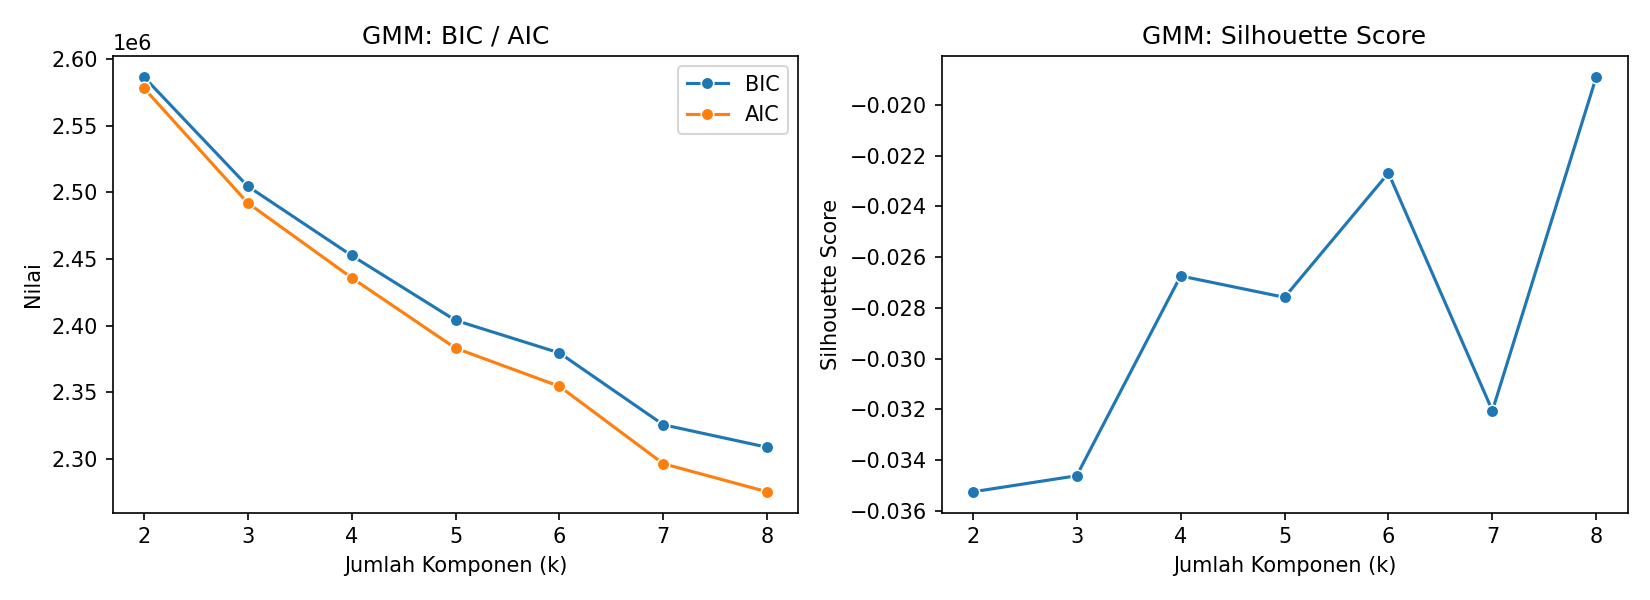

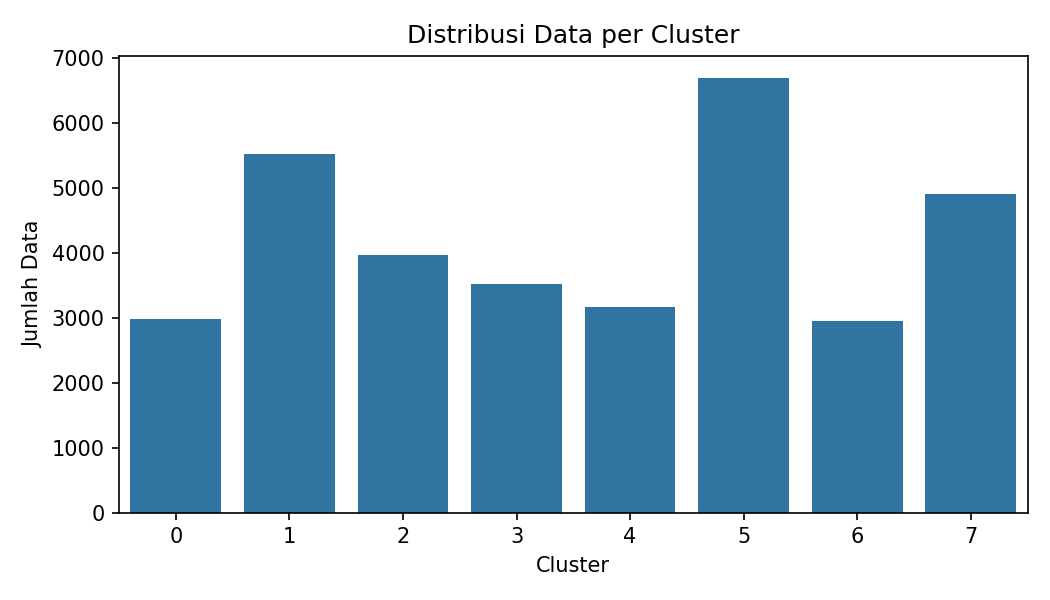

In [30]:
# =========================================================
# 7B. VISUALISASI HASIL GMM
# =========================================================

from IPython.display import Image, display
from pathlib import Path

print("=================================================")
print("STEP 7B: GMM VISUALIZATION")
print("=================================================\n")


# ---------------------------------------------------------
# 1. PATH GAMBAR
# ---------------------------------------------------------
bic_path = FIGURES_DIR / "gmm_bic_silhouette.png"
dist_path = FIGURES_DIR / "gmm_cluster_distribution.png"


print("BIC PATH:", bic_path)
print("EXISTS:", bic_path.exists())

print("DIST PATH:", dist_path)
print("EXISTS:", dist_path.exists())


# ---------------------------------------------------------
# 2. DISPLAY BIC / AIC / SILHOUETTE
# ---------------------------------------------------------
if bic_path.exists():
    display(Image(filename=str(bic_path)))
else:
    print("❌ GMM BIC/Silhouette plot tidak ditemukan")


# ---------------------------------------------------------
# 3. DISPLAY CLUSTER DISTRIBUTION
# ---------------------------------------------------------
if dist_path.exists():
    display(Image(filename=str(dist_path)))
else:
    print("❌ GMM cluster distribution plot tidak ditemukan")

## 6. Supervised Learning: Random Forest, SVM, XGBoost, MLP

Keempat model dilatih dengan train-test split (random_state=42) dan preprocessing yang sama.


In [ ]:
# =========================================================
# 6. SUPERVISED LEARNING (RF, SVM, XGBOOST, MLP)
# =========================================================

from IPython.display import display

print("=================================================")
print("STEP 8: SUPERVISED LEARNING")
print("=================================================\n")


# ---------------------------------------------------------
# PENJELASAN METODE
# ---------------------------------------------------------
print("""
Empat model digunakan untuk klasifikasi AI Usage:

1. Random Forest → ensemble tree-based (robust baseline)
2. Linear SVM → linear classifier baseline
3. XGBoost → gradient boosting (high performance model)
4. MLP Neural Network → deep learning model untuk non-linear pattern

Semua model menggunakan:
- preprocessing yang sama
- stratified train-test split
- random_state = 42 untuk reproducibility
""")


# ---------------------------------------------------------
# TRAIN MODEL
# ---------------------------------------------------------
models, split_data = train_classification_models(
    X,
    y,
    preprocessor,
    test_size=0.2
)


# ---------------------------------------------------------
# INFO DATA SPLIT
# ---------------------------------------------------------
print("\n============= DATA SPLIT =============\n")

print("Ukuran training set:", split_data["X_train"].shape)
print("Ukuran testing set:", split_data["X_test"].shape)


# ---------------------------------------------------------
# MODEL YANG DIGUNAKAN
# ---------------------------------------------------------
print("\n============= MODELS TRAINED =============\n")

for name in models.keys():
    print("-", name)

STEP 8: SUPERVISED LEARNING


Empat model digunakan untuk klasifikasi AI Usage:

1. Random Forest → ensemble tree-based (robust baseline)
2. Linear SVM → linear classifier baseline
3. XGBoost → gradient boosting (high performance model)
4. MLP Neural Network → deep learning model untuk non-linear pattern

Semua model menggunakan:
- preprocessing yang sama
- stratified train-test split
- random_state = 42 untuk reproducibility


============= DATA SPLIT =============

Ukuran training set: (26976, 11)
Ukuran testing set: (6744, 11)

============= MODELS TRAINED =============

- Random Forest
- Linear SVM
- XGBoost
- MLP


## 7. Evaluasi Model Klasifikasi


In [1]:
# =========================================================
# 7. EVALUASI MODEL KLASIFIKASI
# =========================================================

from IPython.display import display

print("=================================================")
print("STEP 9: MODEL EVALUATION")
print("=================================================\n")


# ---------------------------------------------------------
# PENJELASAN SINGKAT EVALUASI
# ---------------------------------------------------------
print("""
Evaluasi model dilakukan menggunakan beberapa metrik:

- Accuracy → tingkat ketepatan total
- Precision → ketepatan prediksi positif
- Recall → kemampuan menangkap kelas positif
- F1-score → keseimbangan precision & recall

Selain itu:
- Confusion Matrix digunakan untuk melihat kesalahan prediksi
- Classification Report digunakan untuk detail per kelas
""")


# ---------------------------------------------------------
# EVALUASI SEMUA MODEL
# ---------------------------------------------------------
classification_results = evaluate_classification_models(
    models,
    split_data["X_test"],
    split_data["y_test"],
)


# ---------------------------------------------------------
# SIMPAN HASIL EVALUASI
# ---------------------------------------------------------
comparison_df = save_classification_outputs(
    classification_results,
    OUTPUT_ROOT
)


# ---------------------------------------------------------
# VISUALISASI HASIL
# ---------------------------------------------------------
plot_confusion_matrices(classification_results, OUTPUT_ROOT)
plot_model_comparison(comparison_df, OUTPUT_ROOT)


# ---------------------------------------------------------
# TAMPILKAN RINGKASAN MODEL
# ---------------------------------------------------------
print("\n============= MODEL COMPARISON =============\n")
display(comparison_df)


# ---------------------------------------------------------
# DETAIL CLASSIFICATION REPORT
# ---------------------------------------------------------
print("\n============= DETAILED REPORT =============\n")

for model_name, result in classification_results.items():

    print("=" * 80)
    print(f"MODEL: {model_name}")
    print("=" * 80)

    print(result["classification_report_text"])

STEP 9: MODEL EVALUATION


Evaluasi model dilakukan menggunakan beberapa metrik:

- Accuracy → tingkat ketepatan total
- Precision → ketepatan prediksi positif
- Recall → kemampuan menangkap kelas positif
- F1-score → keseimbangan precision & recall

Selain itu:
- Confusion Matrix digunakan untuk melihat kesalahan prediksi
- Classification Report digunakan untuk detail per kelas



NameError: name 'evaluate_classification_models' is not defined

## 8. Visualisasi Performa

In [2]:
# =========================================================
# 8. VISUALISASI PERFORMA MODEL
# =========================================================

from IPython.display import Image, display
from pathlib import Path

print("=================================================")
print("STEP 10: MODEL PERFORMANCE VISUALIZATION")
print("=================================================\n")


# ---------------------------------------------------------
# 1. PATH GAMBAR
# ---------------------------------------------------------
img_path = FIGURES_DIR / "model_performance_comparison.png"

print("Image path:", img_path)
print("Exists:", img_path.exists())


# ---------------------------------------------------------
# 2. DISPLAY GAMBAR DENGAN SAFETY CHECK
# ---------------------------------------------------------
if img_path.exists():
    display(Image(filename=str(img_path)))
else:
    print("❌ File tidak ditemukan.")
    print("Pastikan plot_model_comparison sudah dijalankan di cell sebelumnya.")

STEP 10: MODEL PERFORMANCE VISUALIZATION



NameError: name 'FIGURES_DIR' is not defined

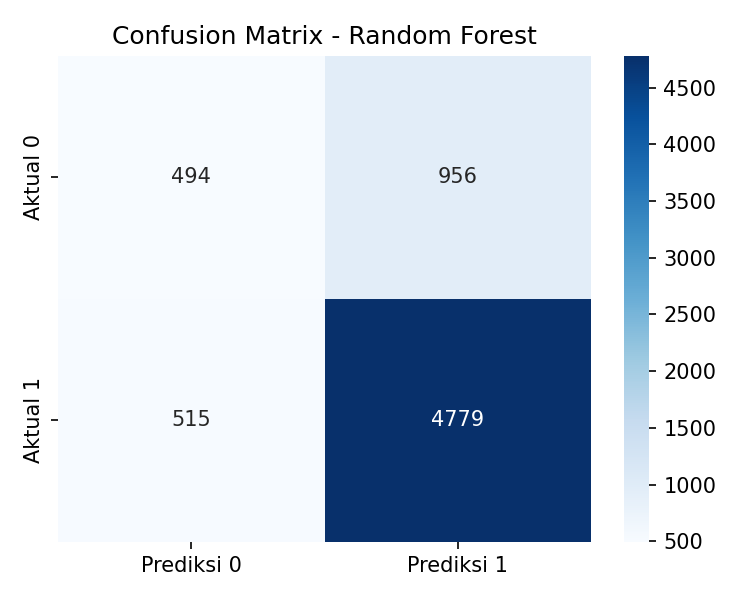

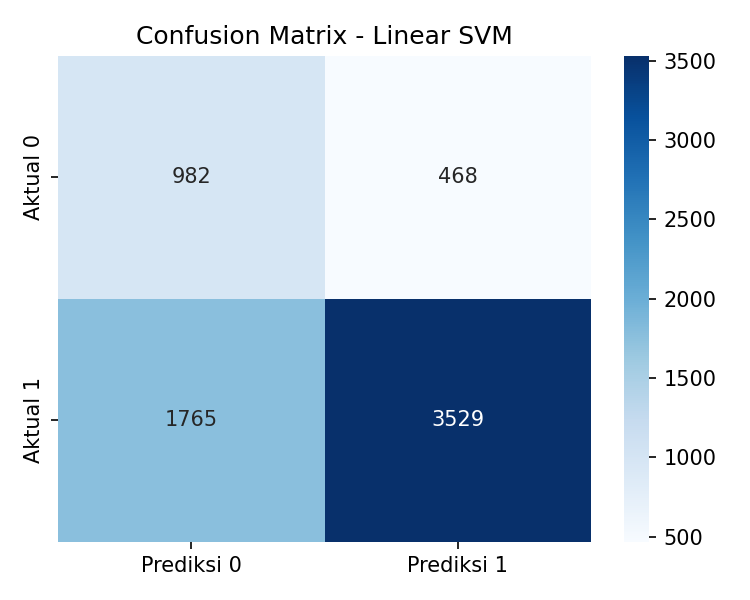

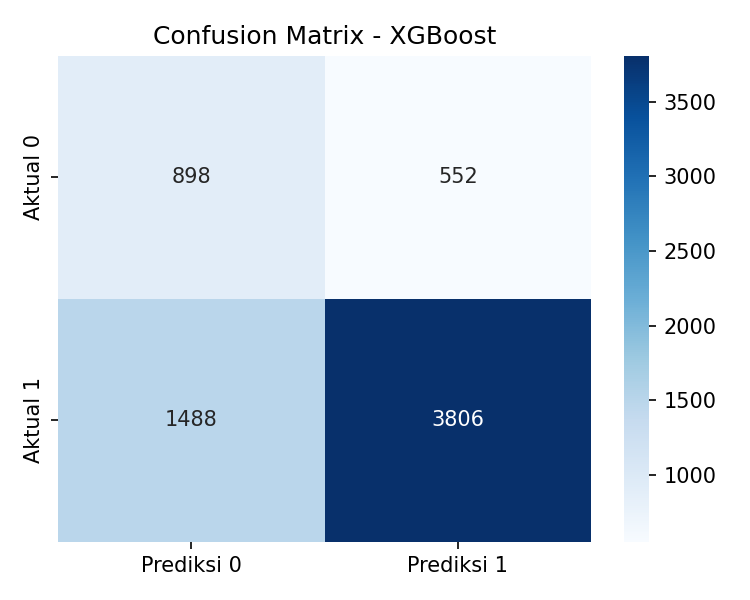

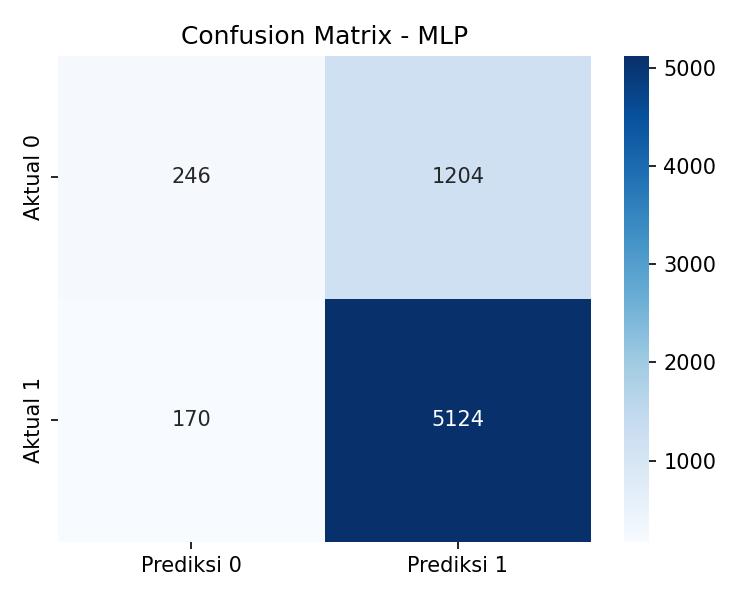

In [ ]:
display(Img(filename=str(FIGURES_DIR / 'confusion_matrix_random_forest.png')))
display(Img(filename=str(FIGURES_DIR / 'confusion_matrix_linear_svm.png')))
display(Img(filename=str(FIGURES_DIR / 'confusion_matrix_xgboost.png')))
display(Img(filename=str(FIGURES_DIR / 'confusion_matrix_mlp.png')))


## 8. Ringkasan untuk BAB IV


In [17]:
best_model_row = comparison_df.sort_values("f1_score", ascending=False).iloc[0]

summary_text = f"""# Ringkasan Awal BAB IV

## Deskripsi Dataset
- Dataset: Stack Overflow Developer Survey 2025.
- Jumlah baris awal: {df.shape[0]:,}.
- Jumlah kolom awal: {df.shape[1]:,}.
- Jumlah data setelah target kosong dibuang: {metadata['n_rows_after_target_drop']:,}.

## Target Prediksi
- Target: AI_Usage.
- Sumber target: {metadata['target_source_col']}.
- Mapping: 1 = menggunakan AI tools, 0 = tidak menggunakan AI tools.
- Distribusi target: {metadata['target_distribution']}.

## Fitur
- Fitur digunakan: {', '.join(metadata['available_features'])}.
- Fitur kandidat yang tidak tersedia: {', '.join(metadata['missing_features']) if metadata['missing_features'] else '-'}.
- Kolom AI tidak dipakai sebagai input untuk menghindari data leakage.

## Preprocessing
- Missing value numerik diisi median.
- Missing value kategorikal diisi Unknown.
- YearsCode/YearsCodePro dikonversi ke numerik jika tersedia.
- Fitur kategorikal di-encode dengan One-Hot Encoding.
- Fitur multi-select dipisahkan berdasarkan titik koma dan diubah menjadi token biner.
- Fitur numerik di-scaling dengan StandardScaler.

## K-Means Clustering
- Rentang k diuji: 2 sampai 10.
- Nilai k terpilih berdasarkan silhouette score tertinggi: {best_k}.
- Tabel interpretasi cluster tersimpan di outputs/tables/cluster_summary.csv.
- Grafik elbow dan silhouette tersimpan di outputs/figures/kmeans_elbow_silhouette.png.

## Evaluasi Model Klasifikasi
- Model terbaik berdasarkan F1-score: {best_model_row['model']}.
- Accuracy: {best_model_row['accuracy']:.4f}.
- Precision: {best_model_row['precision']:.4f}.
- Recall: {best_model_row['recall']:.4f}.
- F1-score: {best_model_row['f1_score']:.4f}.
- Tabel perbandingan model tersimpan di outputs/tables/model_performance_comparison.csv.
"""

report_path = REPORTS_DIR / "bab_iv_ringkasan_awal.md"
report_path.write_text(summary_text, encoding="utf-8")
print(summary_text)
print(f"Ringkasan disimpan ke: {report_path}")

# Ringkasan Awal BAB IV

## Deskripsi Dataset
- Dataset: Stack Overflow Developer Survey 2025.
- Jumlah baris awal: 49,191.
- Jumlah kolom awal: 172.
- Jumlah data setelah target kosong dibuang: 33,720.

## Target Prediksi
- Target: AI_Usage.
- Sumber target: AISelect.
- Mapping: 1 = menggunakan AI tools, 0 = tidak menggunakan AI tools.
- Distribusi target: {0: 7251, 1: 26469}.

## Fitur
- Fitur digunakan: Age, Country, EdLevel, DevType, Employment, RemoteWork, YearsCode, LanguageHaveWorkedWith, DatabaseHaveWorkedWith, PlatformHaveWorkedWith, WebframeHaveWorkedWith.
- Fitur kandidat yang tidak tersedia: YearsCodePro, ToolsTechHaveWorkedWith.
- Kolom AI tidak dipakai sebagai input untuk menghindari data leakage.

## Preprocessing
- Missing value numerik diisi median.
- Missing value kategorikal diisi Unknown.
- YearsCode/YearsCodePro dikonversi ke numerik jika tersedia.
- Fitur kategorikal di-encode dengan One-Hot Encoding.
- Fitur multi-select dipisahkan berdasarkan titik koma dan diub